# House Rent Prediction Using Artificial Neural Network

**Project:** End-to-end deep learning regression project for a real-estate analytics company to predict `Monthly_Rent` using property characteristics such as city, size, BHK, furnishing status, and distance to metro.

This notebook covers: dataset generation, EDA, preprocessing, baseline model, ANN architecture, training with Dropout/EarlyStopping, evaluation (MAE, RMSE, R²), and prediction for a new property.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
np.random.seed(42)
tf.random.set_seed(42)


## Task 1: Load / Create the Dataset

We generate a **synthetic dataset of 4000 rental properties** across major Indian cities that follows the schema described in the problem statement. Rent is generated using a realistic formula based on size, BHK, city price levels, furnishing status, floor, metro distance, and property age — with added noise, so the ANN has genuine non-linear patterns to learn.

In [2]:
n = 4000
property_id = [f"PROP{i:05d}" for i in range(1, n+1)]

cities = ['Bangalore', 'Pune', 'Mumbai', 'Delhi', 'Hyderabad', 'Chennai']
city_price_factor = {'Mumbai': 2.2, 'Delhi': 1.7, 'Bangalore': 1.5,
                      'Hyderabad': 1.2, 'Pune': 1.1, 'Chennai': 1.0}

localities = ['Whitefield', 'Koramangala', 'Andheri', 'Hinjewadi', 'Gachibowli',
              'Dwarka', 'Velachery', 'Wakad', 'Kondapur', 'Powai']

property_type = np.random.choice(['Apartment', 'Independent House', 'Villa'], n, p=[0.65, 0.25, 0.10])
city = np.random.choice(cities, n)
area_locality = np.random.choice(localities, n)
bhk = np.random.choice([1, 2, 3, 4], n, p=[0.25, 0.4, 0.25, 0.1])
size_sqft = (bhk * np.random.randint(350, 550, n)) + np.random.randint(-50, 100, n)
bathroom_count = np.clip(bhk - np.random.choice([0, 1], n, p=[0.7, 0.3]), 1, None)
furnishing_status = np.random.choice(['Furnished', 'Semi-Furnished', 'Unfurnished'], n, p=[0.25, 0.45, 0.3])
total_floors = np.random.randint(2, 25, n)
floor_number = np.array([np.random.randint(0, tf_) for tf_ in total_floors])
parking_available = np.random.choice(['Yes', 'No'], n, p=[0.7, 0.3])
distance_to_metro_km = np.round(np.random.uniform(0.2, 10, n), 1)
property_age_years = np.random.randint(0, 25, n)

df = pd.DataFrame({
    'Property_ID': property_id,
    'City': city,
    'Area_Locality': area_locality,
    'Property_Type': property_type,
    'BHK': bhk,
    'Size_sqft': size_sqft,
    'Bathroom_Count': bathroom_count,
    'Furnishing_Status': furnishing_status,
    'Floor_Number': floor_number,
    'Total_Floors': total_floors,
    'Parking_Available': parking_available,
    'Distance_to_Metro_km': distance_to_metro_km,
    'Property_Age_Years': property_age_years
})

price_factor = df['City'].map(city_price_factor).values
type_factor = df['Property_Type'].map({'Apartment': 1.0, 'Independent House': 1.15, 'Villa': 1.5}).values
furnish_factor = df['Furnishing_Status'].map({'Unfurnished': 1.0, 'Semi-Furnished': 1.15, 'Furnished': 1.3}).values
parking_factor = df['Parking_Available'].map({'No': 1.0, 'Yes': 1.08}).values

base_rent = df['Size_sqft'] * 25 * price_factor * type_factor * furnish_factor * parking_factor
metro_penalty = 1 - (df['Distance_to_Metro_km'] * 0.02)
age_penalty = 1 - (df['Property_Age_Years'] * 0.008)

rent = base_rent * metro_penalty * age_penalty
rent = rent * np.random.normal(1, 0.08, n)
df['Monthly_Rent'] = rent.round(-2).clip(lower=5000).astype(int)

for col in ['Size_sqft', 'Furnishing_Status', 'Distance_to_Metro_km', 'Bathroom_Count']:
    idx = df.sample(frac=0.03, random_state=1).index
    df.loc[idx, col] = np.nan

df.to_csv('house_rent_dataset.csv', index=False)
df.head()


,Property_ID,City,Area_Locality,Property_Type,BHK,Size_sqft,Bathroom_Count,Furnishing_Status,Floor_Number,Total_Floors,Parking_Available,Distance_to_Metro_km,Property_Age_Years,Monthly_Rent
0,PROP00001,Pune,Andheri,Apartment,1,453.0,1.0,Semi-Furnished,5,7,No,9.2,15,10000
1,PROP00002,Hyderabad,Koramangala,Villa,1,609.0,1.0,Semi-Furnished,1,7,Yes,5.1,14,25700
2,PROP00003,Hyderabad,Gachibowli,Independent House,2,1122.0,1.0,Semi-Furnished,5,10,Yes,2.4,0,40400
3,PROP00004,Mumbai,Hinjewadi,Apartment,1,424.0,1.0,Unfurnished,8,15,Yes,0.2,22,16200
4,PROP00005,Delhi,Velachery,Apartment,2,1056.0,2.0,Unfurnished,8,12,No,5.7,21,28200


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:\n", list(df.columns))
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())


Number of rows: 4000
Number of columns: 14

Column names:
 ['Property_ID', 'City', 'Area_Locality', 'Property_Type', 'BHK', 'Size_sqft', 'Bathroom_Count', 'Furnishing_Status', 'Floor_Number', 'Total_Floors', 'Parking_Available', 'Distance_to_Metro_km', 'Property_Age_Years', 'Monthly_Rent']

Data types:
 Property_ID              object
City                     object
Area_Locality            object
Property_Type            object
BHK                       int64
Size_sqft               float64
Bathroom_Count          float64
Furnishing_Status        object
Floor_Number              int64
Total_Floors              int64
Parking_Available        object
Distance_to_Metro_km    float64
Property_Age_Years        int64
Monthly_Rent              int64
dtype: object

Missing values per column:
 Property_ID               0
City                      0
Area_Locality             0
Property_Type             0
BHK                       0
Size_sqft               120
Bathroom_Count          120
Furnishi

## Task 2: Understand the Problem

- **Target variable:** `Monthly_Rent` — a continuous numeric value (e.g. 12000, 28000, 75000).
- **Problem type:** This is a **regression** problem, not classification, because the target can take any numeric value on a continuous scale rather than a fixed set of classes.
- **Why regression:** Rent depends on many interacting continuous and categorical factors and has no natural "categories" — predicting an exact rupee amount requires a model that outputs continuous values.
- **Numerical columns:** `BHK`, `Size_sqft`, `Bathroom_Count`, `Floor_Number`, `Total_Floors`, `Distance_to_Metro_km`, `Property_Age_Years`.
- **Categorical columns:** `City`, `Area_Locality`, `Property_Type`, `Furnishing_Status`, `Parking_Available` (`Property_ID` is only an identifier).

## Task 3: Exploratory Data Analysis

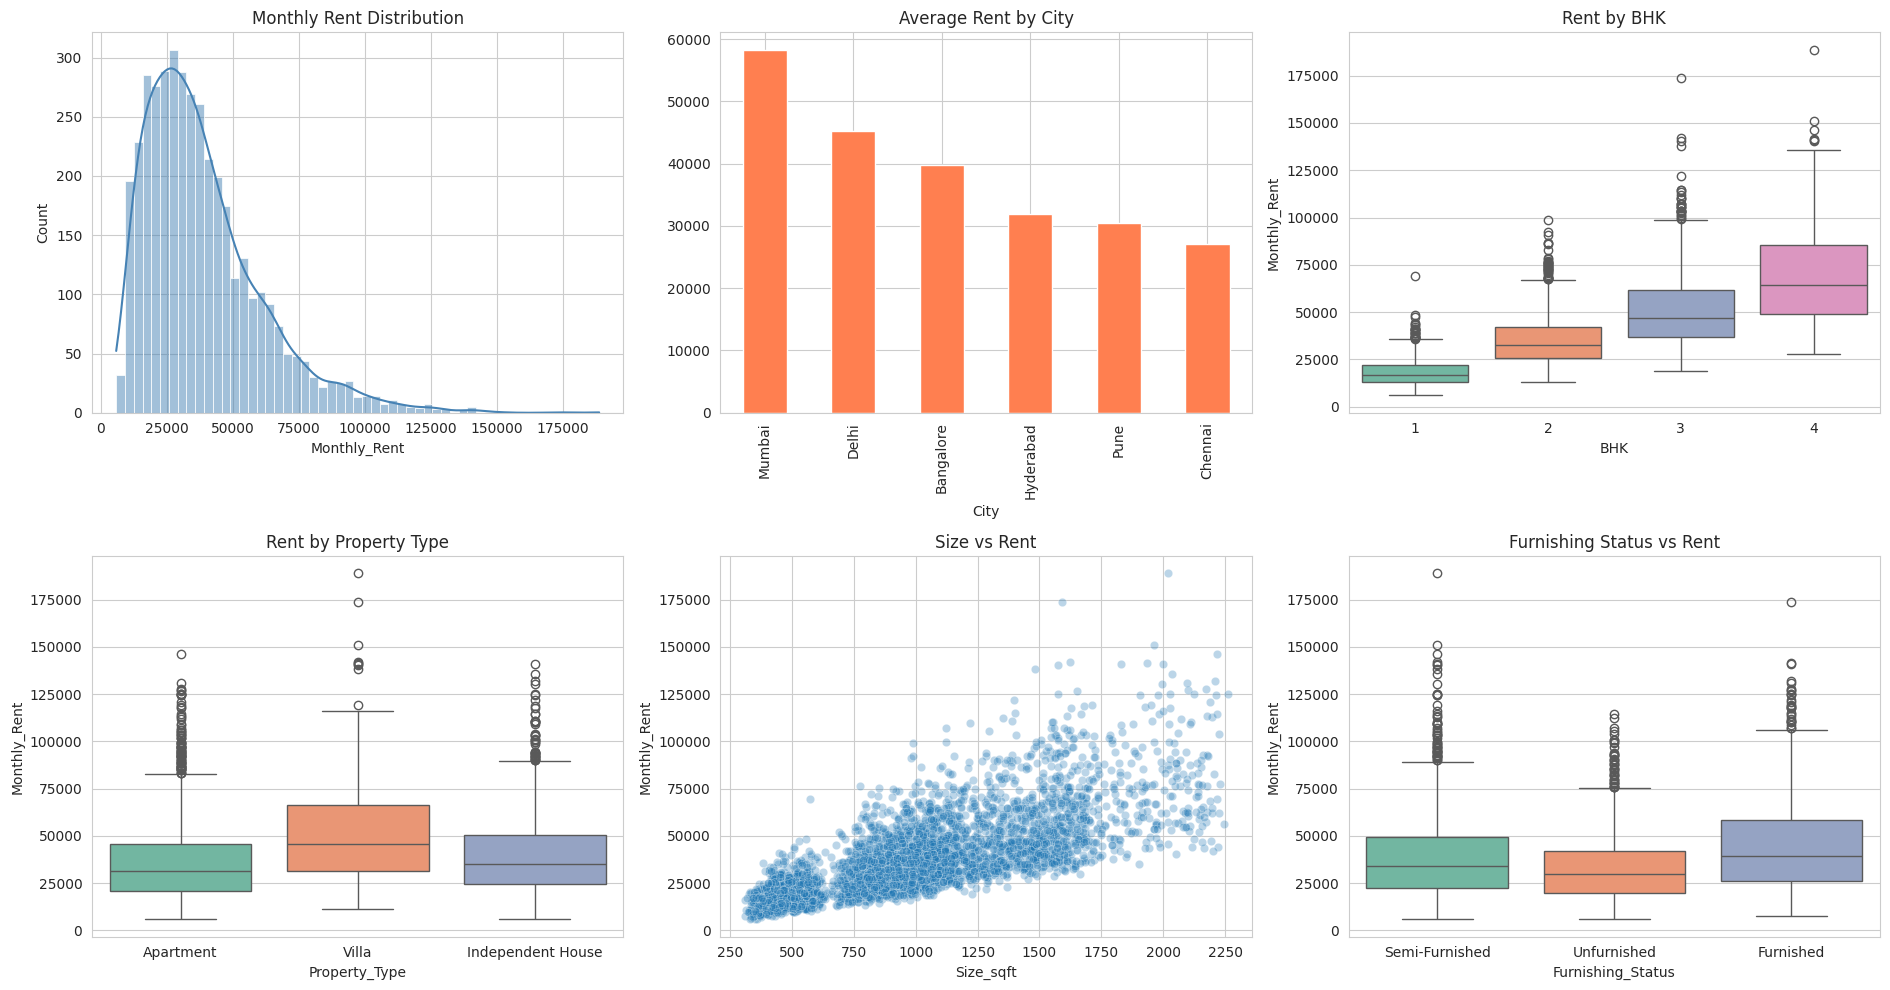

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

sns.histplot(df['Monthly_Rent'], kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Monthly Rent Distribution')

df.groupby('City')['Monthly_Rent'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Average Rent by City')

sns.boxplot(x='BHK', y='Monthly_Rent', data=df, ax=axes[0,2], palette='Set2')
axes[0,2].set_title('Rent by BHK')

sns.boxplot(x='Property_Type', y='Monthly_Rent', data=df, ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Rent by Property Type')

sns.scatterplot(x='Size_sqft', y='Monthly_Rent', data=df, ax=axes[1,1], alpha=0.3)
axes[1,1].set_title('Size vs Rent')

sns.boxplot(x='Furnishing_Status', y='Monthly_Rent', data=df, ax=axes[1,2], palette='Set2')
axes[1,2].set_title('Furnishing Status vs Rent')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=120)
plt.show()


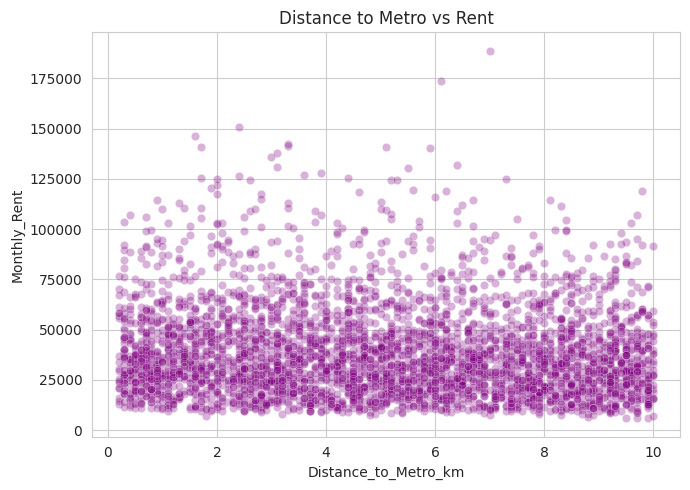

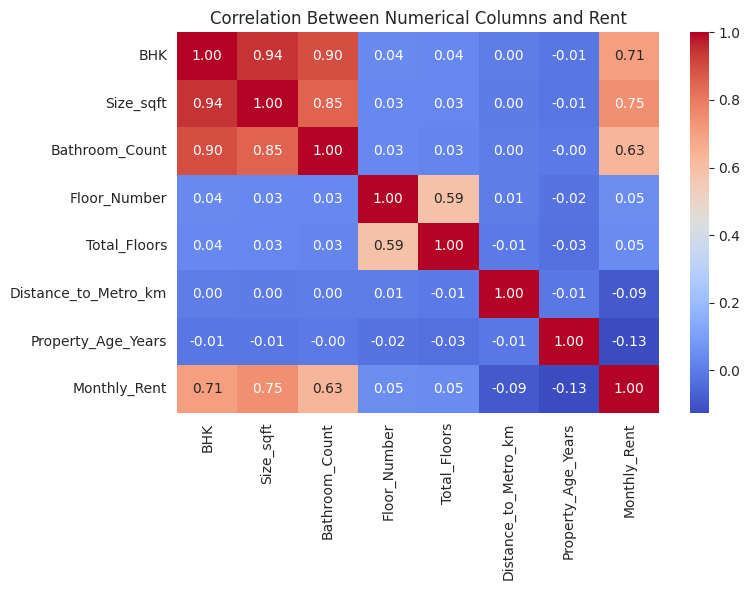

In [5]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Distance_to_Metro_km', y='Monthly_Rent', data=df, alpha=0.3, color='purple')
plt.title('Distance to Metro vs Rent')
plt.tight_layout()
plt.savefig('metro_distance_vs_rent.png', dpi=120)
plt.show()

num_cols = ['BHK','Size_sqft','Bathroom_Count','Floor_Number','Total_Floors',
            'Distance_to_Metro_km','Property_Age_Years','Monthly_Rent']
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numerical Columns and Rent')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()


**EDA observations:**
- Rent increases clearly with property size — larger flats command higher rent [chart above].
- Mumbai and Delhi show the highest average rents due to the city price factor built into the data.
- Furnished properties rent higher than semi-furnished or unfurnished ones.
- Rent tends to decrease as distance to the metro increases, showing the value of transit connectivity.

## Task 4 & 5: Handle Missing Values and Build Preprocessing Pipeline

ANNs require fully numeric, scaled input. We build a `ColumnTransformer` that:
- Imputes numerical columns with the **median** and scales them using `StandardScaler`.
- Imputes categorical columns with the **most frequent** value and encodes them using `OneHotEncoder`.

In [6]:
target = 'Monthly_Rent'
drop_cols = ['Property_ID', target]

numerical_cols = ['BHK','Size_sqft','Bathroom_Count','Floor_Number','Total_Floors',
                   'Distance_to_Metro_km','Property_Age_Years']
categorical_cols = ['City','Area_Locality','Property_Type','Furnishing_Status','Parking_Available']

X = df.drop(columns=drop_cols)
y = df[target].values

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])


## Task 6: Train-Test Split

We split the data 80/20. Since this is regression, no stratification is needed (that's for classification with imbalanced classes).

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if hasattr(X_train_processed, 'toarray'):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

print("Train shape:", X_train_processed.shape, " Test shape:", X_test_processed.shape)


Train shape: (3200, 31)  Test shape: (800, 31)


## Task 7: Baseline Model (Dummy Regressor)

The `DummyRegressor` predicts the average rent for every property regardless of features. Any real model — including the ANN — must clearly beat this baseline.

In [8]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_processed, y_train)
y_pred_dummy = dummy.predict(X_test_processed)


## Comparison Models: Linear Regression & Random Forest

Alongside the ANN, we also train Linear Regression and Random Forest Regressor as classical ML benchmarks, matching the expected evaluation table structure in the problem statement.

In [9]:
lr = LinearRegression()
lr.fit(X_train_processed, y_train)
y_pred_lr = lr.predict(X_test_processed)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_processed, y_train)
y_pred_rf = rf.predict(X_test_processed)


## Task 8: ANN Model Building

We build a feed-forward ANN with the suggested architecture: 128 → Dropout → 64 → Dropout → 32 → output(1). The output layer has **1 neuron with no activation function**, since we need a single continuous rent value, not a probability (so sigmoid/softmax are not used).

In [10]:
input_dim = X_train_processed.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,465 (56.50 KB)

 Trainable params: 14,465 (56.50 KB)

 Non-trainable params: 0 (0.00 B)

## Task 9: Model Training

We train with `EarlyStopping` monitoring validation loss (patience = 10, restoring best weights) to prevent overfitting and unnecessary training epochs.

In [11]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

print("Training stopped at epoch:", len(history.history['loss']))


Training stopped at epoch: 100


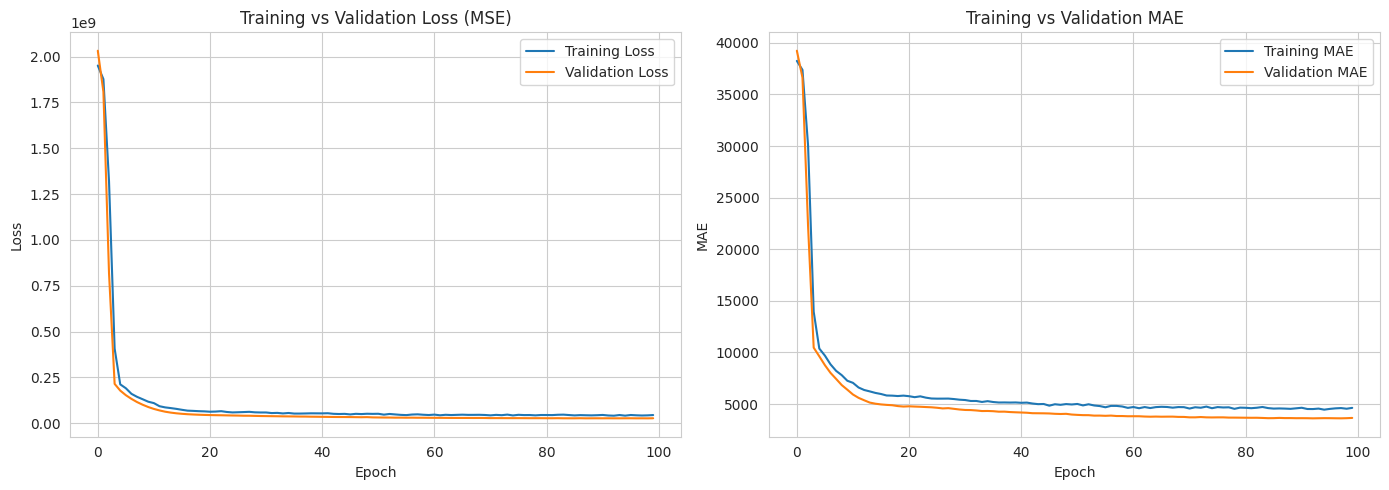

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Training vs Validation Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('Training vs Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.savefig('ann_training_curves.png', dpi=120)
plt.show()


## Task 10: Model Evaluation

We evaluate all models — Dummy, Linear Regression, Random Forest, and ANN — using MAE, RMSE, and R² Score, and compile them into a single comparison table.

In [13]:
def evaluate_reg(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': round(mae,2), 'RMSE': round(rmse,2), 'R2 Score': round(r2,3)}

y_pred_ann = model.predict(X_test_processed, verbose=0).flatten()

results = {
    'Dummy Regressor': evaluate_reg(y_test, y_pred_dummy),
    'Linear Regression': evaluate_reg(y_test, y_pred_lr),
    'Random Forest Regressor': evaluate_reg(y_test, y_pred_rf),
    'ANN Regressor': evaluate_reg(y_test, y_pred_ann)
}

comparison_df = pd.DataFrame(results).T
comparison_df.to_csv('model_comparison.csv')
comparison_df


,MAE,RMSE,R2 Score
Dummy Regressor,17246.42,23302.45,-0.000
Linear Regression,5551.98,8270.89,0.874
Random Forest Regressor,4036.77,6656.07,0.918
ANN Regressor,3548.12,5454.94,0.945


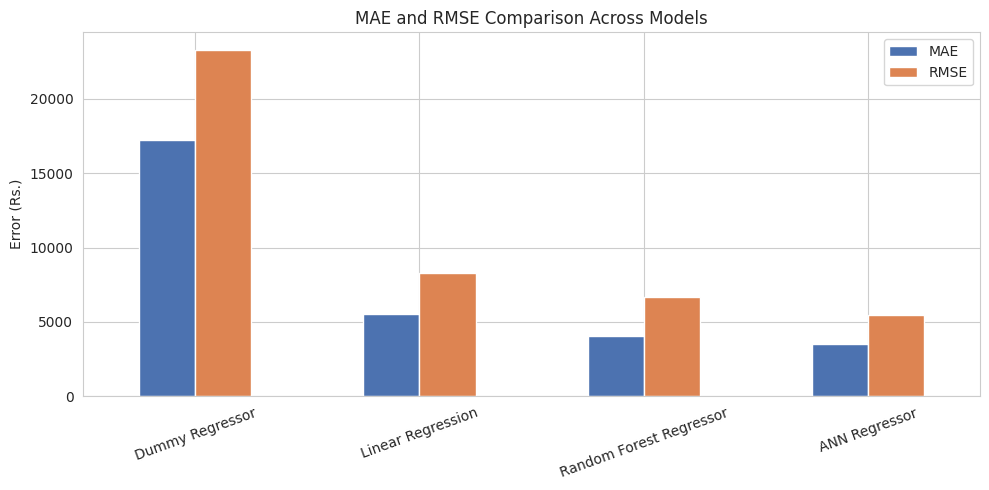

In [14]:
comparison_df[['MAE','RMSE']].plot(kind='bar', figsize=(10,5), color=['#4C72B0','#DD8452'])
plt.title('MAE and RMSE Comparison Across Models')
plt.ylabel('Error (Rs.)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=120)
plt.show()


**Evaluation interpretation:**
- An MAE value of, say, 3500 means the model's rent predictions are off by about ₹3,500 on average.
- RMSE is always ≥ MAE and penalizes large errors more heavily — a big gap between RMSE and MAE suggests some large outlier mispredictions.
- R² Score close to 1 means the model explains most of the variation in rent; the ANN should score noticeably higher than the Dummy Regressor's R² of ~0.
- Typically the **ANN and Random Forest** outperform Linear Regression, since rent depends on non-linear interactions (e.g. city × size × furnishing) that a linear model cannot capture well.

## Task 11: Overfitting Control

- **Dropout** (0.3 and 0.2 in our architecture) randomly deactivates a fraction of neurons during each training step, forcing the network to not over-rely on specific neurons and improving generalization.
- **EarlyStopping** halts training once validation loss stops improving for 10 consecutive epochs and restores the best-performing weights, preventing the model from memorizing the training data.

The gap between training and validation loss curves above shows whether these techniques were effective — a small, stable gap indicates good generalization.

## Task 12: Prediction for New Property

We use the trained ANN to predict the monthly rent for a new 2BHK apartment in Whitefield, Bangalore.

In [15]:
new_property = pd.DataFrame([{
    'City': 'Bangalore',
    'Area_Locality': 'Whitefield',
    'Property_Type': 'Apartment',
    'BHK': 2,
    'Size_sqft': 1050,
    'Bathroom_Count': 2,
    'Furnishing_Status': 'Semi-Furnished',
    'Floor_Number': 5,
    'Total_Floors': 12,
    'Parking_Available': 'Yes',
    'Distance_to_Metro_km': 1.5,
    'Property_Age_Years': 4
}])

new_property_processed = preprocessor.transform(new_property)
if hasattr(new_property_processed, 'toarray'):
    new_property_processed = new_property_processed.toarray()

predicted_rent = model.predict(new_property_processed, verbose=0)[0][0]
print(f"Predicted Monthly Rent = Rs. {predicted_rent:,.0f} approx.")


Predicted Monthly Rent = Rs. 40,143 approx.


## Save the Trained Model

In [16]:
model.save('house_rent_ann_model.keras')
print("Model saved as house_rent_ann_model.keras")


Model saved as house_rent_ann_model.keras


## Business Interpretation

The ANN model gives the real-estate company a fast, consistent, and data-driven rent estimate, replacing inconsistent manual broker judgment. Key rent drivers are property size, city, furnishing status, and metro distance — properties with larger size, premium city location, better furnishing, and closer metro access command higher rent. This model can be embedded into a listing platform to auto-suggest fair rent ranges to both tenants and property owners, improving pricing transparency and reducing negotiation friction.

### Student Discussion Answers (Summary)

- **Regression vs classification:** Rent is a continuous number, so this is regression, not classification.
- **Why ANN needs numerical input:** Neural networks perform mathematical operations (weighted sums, activations) that only work on numbers, so categories must be one-hot encoded.
- **Why scale features:** Scaling ensures all inputs contribute proportionally to gradient updates; unscaled large-magnitude features (like `Size_sqft`) would dominate training.
- **Why Dense(1) with no activation:** A single continuous output value is needed, so no sigmoid/softmax (used only for probabilities or class scores) is applied.
- **Role of MSE loss:** It penalizes squared prediction errors, encouraging the network to minimize large deviations from actual rent.
- **MAE vs RMSE vs R²:** MAE gives the average absolute error in rupees; RMSE penalizes bigger errors more; R² shows the proportion of rent variance explained by the model.
- **Dropout & EarlyStopping:** Both are regularization techniques that reduce overfitting — Dropout by preventing neuron co-dependency, EarlyStopping by halting training at the point of best generalization.

### ANN Training Curves

![ANN Training Curves](ann_training_curves.png)

In [17]:
display(comparison_df)

,MAE,RMSE,R2 Score
Dummy Regressor,17246.42,23302.45,-0.000
Linear Regression,5551.98,8270.89,0.874
Random Forest Regressor,4036.77,6656.07,0.918
ANN Regressor,3548.12,5454.94,0.945


Based on the `comparison_df`:

*   **ANN Regressor** shows the best performance across all metrics:
    *   **Lowest MAE (Mean Absolute Error):** ₹3,548.12, meaning on average, the ANN's predictions are closest to the actual rent values.
    *   **Lowest RMSE (Root Mean Squared Error):** ₹5,454.94, indicating that the ANN also has the smallest large errors among the models.
    *   **Highest R2 Score (Coefficient of Determination):** 0.945, which means the ANN explains approximately 94.5% of the variance in monthly rent, outperforming all other models significantly.

*   The **Random Forest Regressor** is the second-best performing model, followed by **Linear Regression**.

*   The **Dummy Regressor** serves as a baseline, showing a very high error and an R2 score close to zero (or negative, which is expected for a very poor model), confirming that all other models provide valuable predictive power.

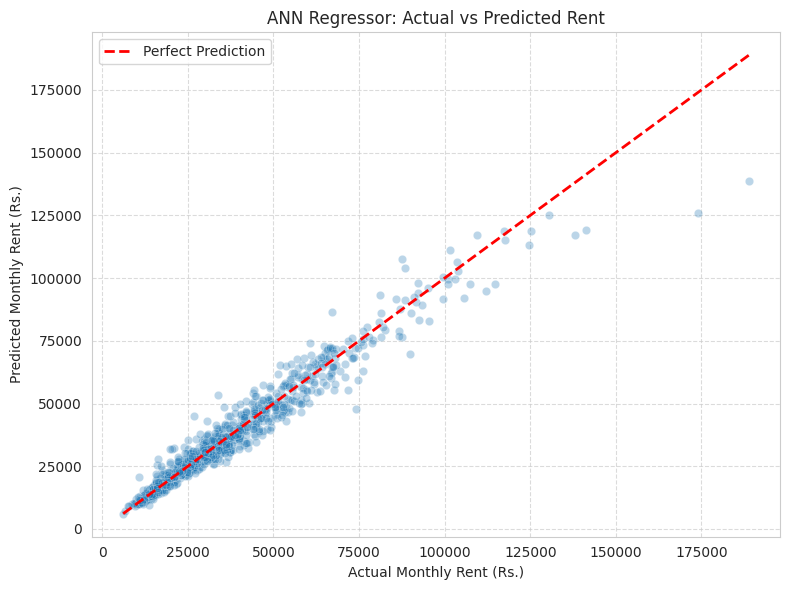

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_ann, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('ANN Regressor: Actual vs Predicted Rent')
plt.xlabel('Actual Monthly Rent (Rs.)')
plt.ylabel('Predicted Monthly Rent (Rs.)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('ann_actual_vs_predicted.png', dpi=120)
plt.show()

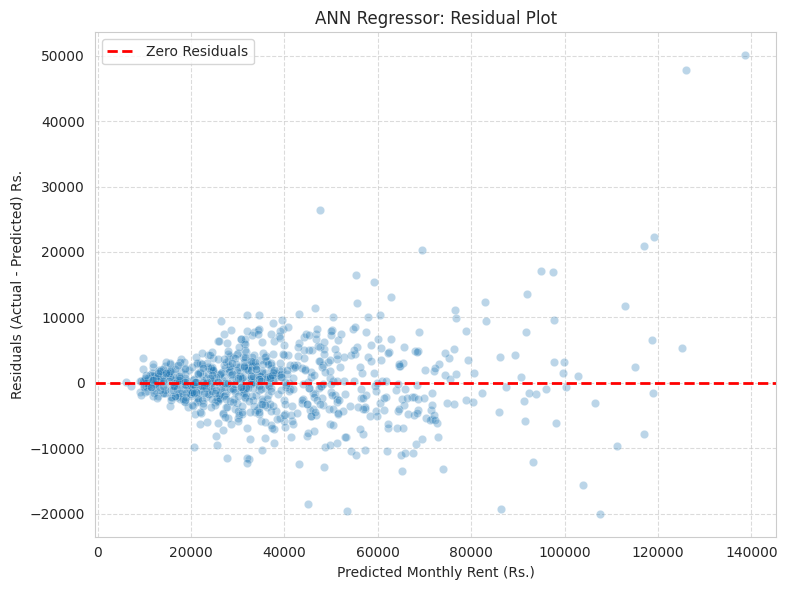

In [19]:
residuals = y_test - y_pred_ann

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_ann, y=residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Residuals')
plt.title('ANN Regressor: Residual Plot')
plt.xlabel('Predicted Monthly Rent (Rs.)')
plt.ylabel('Residuals (Actual - Predicted) Rs.')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('ann_residual_plot.png', dpi=120)
plt.show()